# Task 2 — Trends and the spaghetti problem (Gapminder)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlesize": 11,
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "legend.frameon": False, "font.size": 10, "savefig.dpi": 150, "savefig.bbox": "tight",
})


def finish(fig, title, subtitle=None, note=None, name=None):
    fig.tight_layout()
    tr = lambda y: offset_copy(fig.transFigure, fig=fig, y=y, units="points")
    if subtitle:
        fig.text(0.01, 1, subtitle, va="bottom", fontsize=10, color=INK_SOFT, transform=tr(4))
    fig.text(0.01, 1, title, va="bottom", fontsize=14, fontweight="bold", color=INK,
             transform=tr(22 if subtitle else 6))
    if note:
        fig.text(0.01, 0, note, va="top", fontsize=9, color=INK_MUTED, transform=tr(-4))
    if name:
        fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)
    plt.show()

In [2]:
gap = pd.read_csv(DATA / "gapminder.csv")
print(gap.shape, "missing:", gap.isna().sum().sum())
print(gap["country"].nunique(), "countries,", gap["year"].nunique(), "years")
gap.groupby("continent")["country"].nunique()

(1704, 6) missing: 0
142 countries, 12 years


continent
Africa      52
Americas    25
Asia        33
Europe      30
Oceania      2
Name: country, dtype: int64

Clean and balanced: 142 countries x 12 years, no missing values. Oceania only has 2 countries (Australia, New Zealand).

## 1. The messy chart (on purpose)

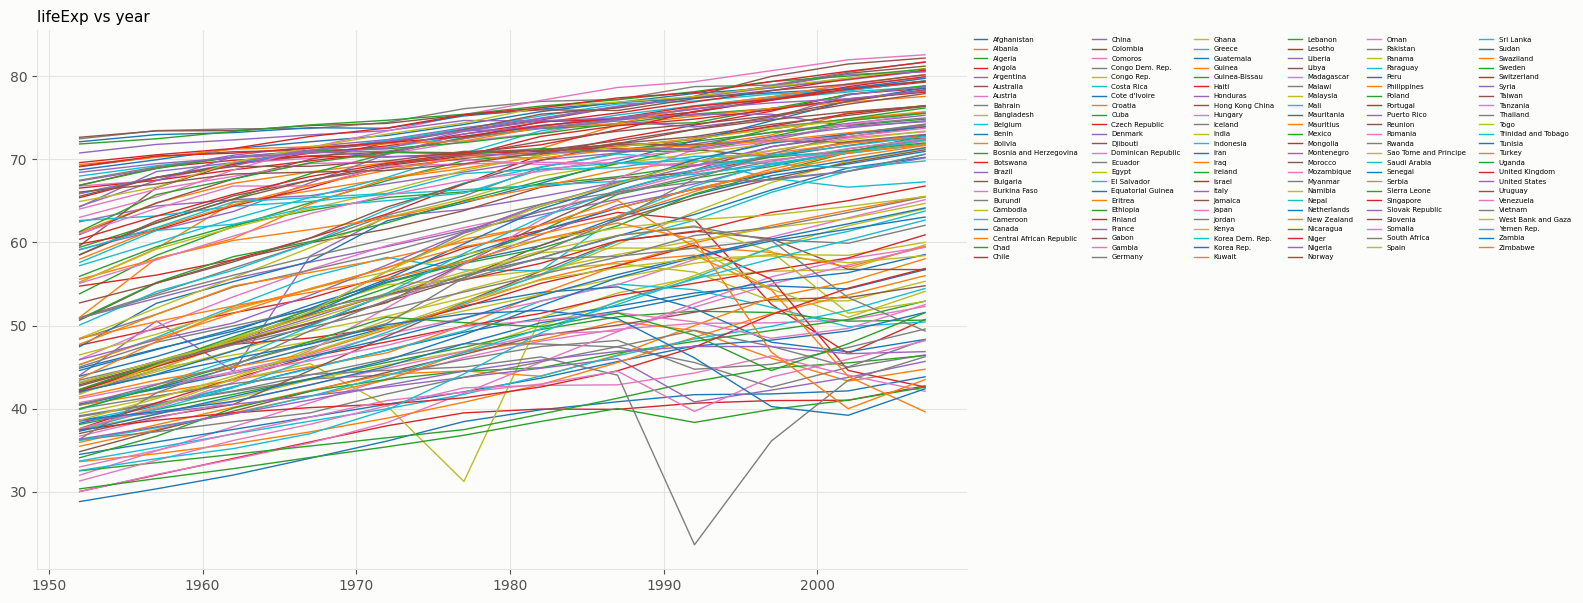

In [3]:
fig, ax = plt.subplots(figsize=(12, 7))
for country, d in gap.groupby("country"):
    ax.plot(d["year"], d["lifeExp"], label=country, linewidth=1)
ax.legend(ncol=6, fontsize=5, loc="upper left", bbox_to_anchor=(1, 1))
ax.set_title("lifeExp vs year")
plt.show()

**Chart analysis.**

142 lines are drawn on top of each other and the legend is bigger than the chart.  
The same few colours keep repeating, so colour tells you nothing.  
You cannot follow a single country in here.

What's wrong with it:

- 142 lines on top of each other, you can't follow any single one.
- The legend has 142 entries and is bigger than the chart. Nobody can match a colour to a country.
- Matplotlib only has ~10 default colours so they repeat — the same blue is used for many countries.
  Colour doesn't mean anything here.
- The title is just the column names, it doesn't tell you what the chart shows.
- No axis labels or units.
- There's no message. You can maybe see "it goes up" but that's it.

## 2a. Fix by aggregating: one line per continent

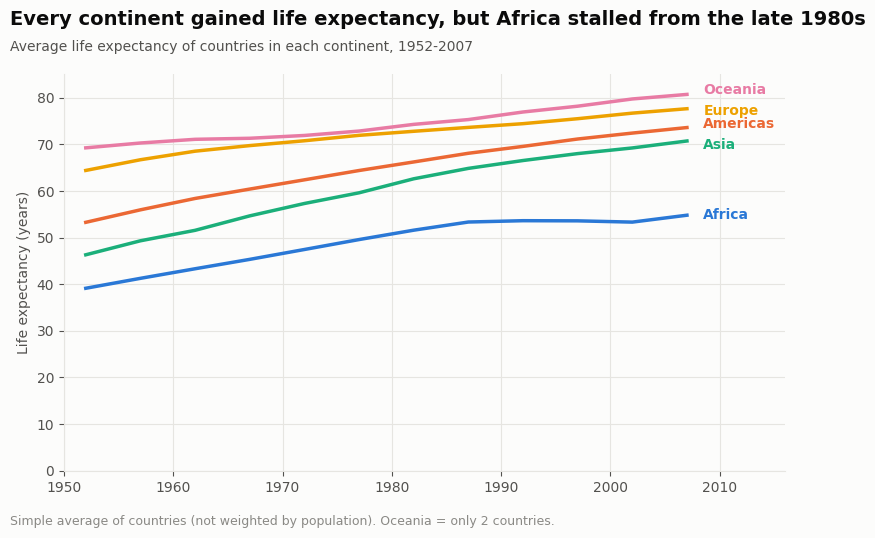

In [4]:
cont = gap.groupby(["continent", "year"])["lifeExp"].mean().unstack(0)

fig, ax = plt.subplots()
for color, c in zip(SERIES, cont.columns):
    ax.plot(cont.index, cont[c], color=color, linewidth=2.5)
    nudge = {"Oceania": 1, "Europe": -0.5, "Americas": 0.8, "Asia": -0.8}.get(c, 0)
    ax.text(2008.5, cont[c].iloc[-1] + nudge, c, color=color, va="center", fontweight="bold")
ax.set_xlim(1950, 2016)
ax.set_ylim(0, 85)
ax.set_ylabel("Life expectancy (years)")

finish(fig, "Every continent gained life expectancy, but Africa stalled from the late 1980s",
       "Average life expectancy of countries in each continent, 1952-2007",
       "Simple average of countries (not weighted by population). Oceania = only 2 countries.",
       name="task2a_continents")

**Chart analysis.**

One line per continent makes the rising trend easy to see.  
All five continents improved over the years.  
But an average hides what happened inside each continent.

**Why this chart:** change over time → line chart. 5 lines is readable so I labelled them at the end of
each line instead of using a legend. Colour here just separates the continents. The y-axis starts at 0 so
the gaps between continents aren't exaggerated.

## 2b. Fix by highlighting 3 countries

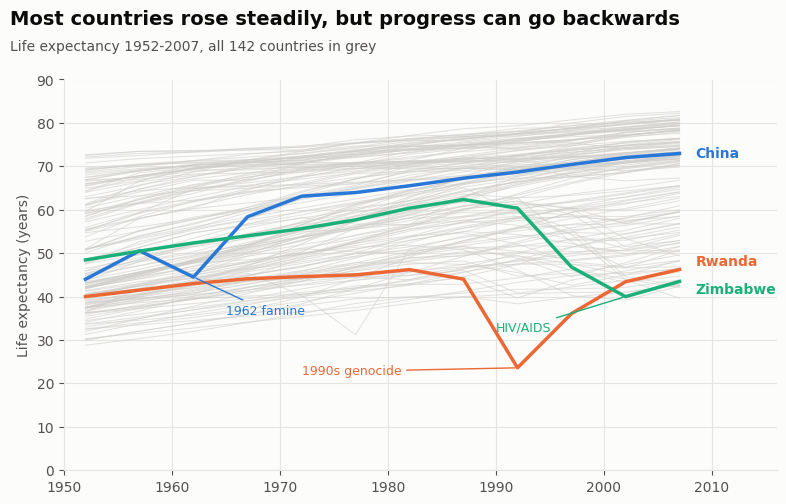

In [5]:
highlight = {"China": BLUE, "Rwanda": ORANGE, "Zimbabwe": AQUA}
nudge = {"Rwanda": 1.8, "Zimbabwe": -1.8}

fig, ax = plt.subplots()
for country, d in gap.groupby("country"):
    if country not in highlight:
        ax.plot(d["year"], d["lifeExp"], color=QUIET, linewidth=0.7, alpha=0.6)
for country, color in highlight.items():
    d = gap[gap["country"] == country]
    ax.plot(d["year"], d["lifeExp"], color=color, linewidth=2.5)
    ax.text(2008.5, d["lifeExp"].iloc[-1] + nudge.get(country, 0), country, color=color, va="center", fontweight="bold")

ax.annotate("1962 famine", xy=(1962, 44.5), xytext=(1965, 36), color=BLUE, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=BLUE))
ax.annotate("1990s genocide", xy=(1992, 23.6), xytext=(1972, 22), color=ORANGE, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=ORANGE))
ax.annotate("HIV/AIDS", xy=(2002, 40), xytext=(1990, 32), color=AQUA, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=AQUA))
ax.set_xlim(1950, 2016)
ax.set_ylim(0, 90)
ax.set_ylabel("Life expectancy (years)")

finish(fig, "Most countries rose steadily, but progress can go backwards",
       "Life expectancy 1952-2007, all 142 countries in grey",
       name="task2b_highlight")

**Chart analysis.**

Only three countries are coloured, the rest are left grey.  
China dips around 1962, Rwanda crashes in 1992, Zimbabwe falls from the late 1980s.  
The grey keeps all the data there without the mess.

**Why this chart:** still a line chart because it's a trend, but grey for context and colour only for the 3
countries I want to talk about. Direct labels so no legend is needed. I picked China (big dip in 1962 then
a steady climb), Rwanda (collapse around the genocide) and Zimbabwe (going backwards from the late 80s
because of HIV/AIDS).

## 3. Comparing (a) and (b)

(a) shows the big picture clearly — the general upward trend and the gap between continents — but an
average hides everything happening inside a continent. You'd never guess from the Africa line that Rwanda
dropped to 24 years or that Zimbabwe went backwards for 20 years.

(b) keeps every country so you can see the spread and the individual stories, but it's harder to read off
an overall trend or compare continents, and it only works if you already know which countries to pick.

So (a) is better for "what's the general pattern", (b) for "what are the exceptions".

## Watch out: gdpPercap is skewed

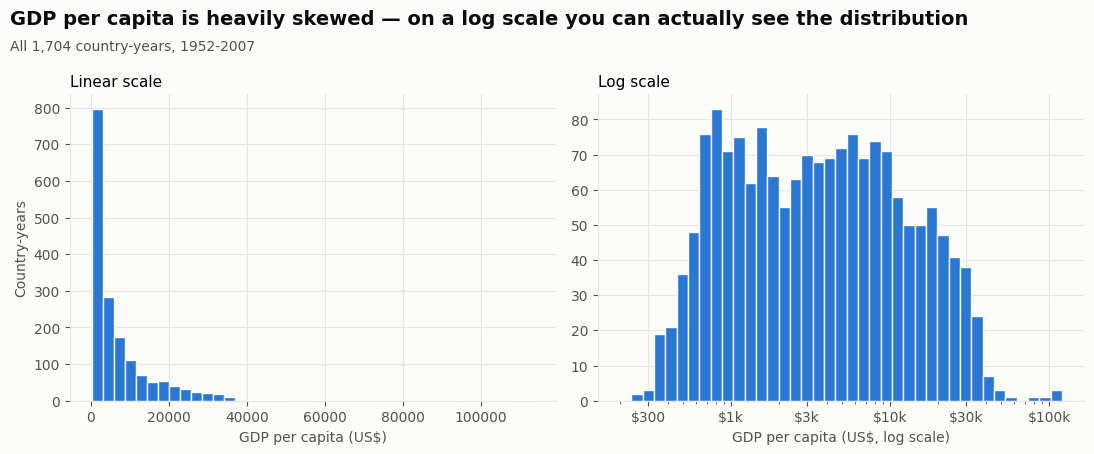

count      1704.0
mean       7215.0
std        9857.0
min         241.0
25%        1202.0
50%        3532.0
75%        9325.0
max      113523.0
Name: gdpPercap, dtype: float64

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.hist(gap["gdpPercap"], bins=40, color=BLUE, edgecolor=SURFACE)
ax1.set_title("Linear scale")
ax1.set_xlabel("GDP per capita (US$)")
ax1.set_ylabel("Country-years")

ax2.hist(gap["gdpPercap"], bins=np.logspace(np.log10(200), np.log10(120000), 40), color=BLUE, edgecolor=SURFACE)
ax2.set_xscale("log")
ax2.set_xticks([300, 1000, 3000, 10000, 30000, 100000], ["$300", "$1k", "$3k", "$10k", "$30k", "$100k"])
ax2.set_title("Log scale")
ax2.set_xlabel("GDP per capita (US$, log scale)")

finish(fig, "GDP per capita is heavily skewed — on a log scale you can actually see the distribution",
       "All 1,704 country-years, 1952-2007", name="task2_gdp_hist")
gap["gdpPercap"].describe().round(0)

**Chart analysis.**

On the normal scale almost every bar is squashed on the left.  
A few very rich years stretch the axis all the way to $113k.  
The log scale spreads them out so the real shape shows.

On the linear scale almost everything is squashed into the first few bars and a handful of very rich
country-years (mostly Kuwait) stretch the axis to $113k. The mean ($7.2k) is double the median ($3.5k).
On a log scale each step is ×10 instead of +$10k, so poor and rich countries both get space and the shape
becomes readable.

I'll use a log scale for the gap question, because "gap" between rich and poor is really about *how many
times* richer, which is exactly what equal distances on a log axis show.

## 4. Has the gap between richest and poorest narrowed since 1952?

In [7]:
pct = gap.groupby("year")["gdpPercap"].quantile([0.1, 0.5, 0.9]).unstack()
pct.columns = ["p10", "median", "p90"]
pct["ratio"] = pct["p90"] / pct["p10"]
pct.round(0)

,p10,median,p90,ratio
year,,,,
1952,495.0,1969.0,7255.0,15.0
1957,576.0,2173.0,9668.0,17.0
1962,603.0,2335.0,10967.0,18.0
1967,702.0,2678.0,14061.0,20.0
1972,724.0,3339.0,16606.0,23.0
1977,741.0,3799.0,19092.0,26.0
1982,790.0,4216.0,19468.0,25.0
1987,738.0,4280.0,21866.0,30.0
1992,737.0,4386.0,24752.0,34.0


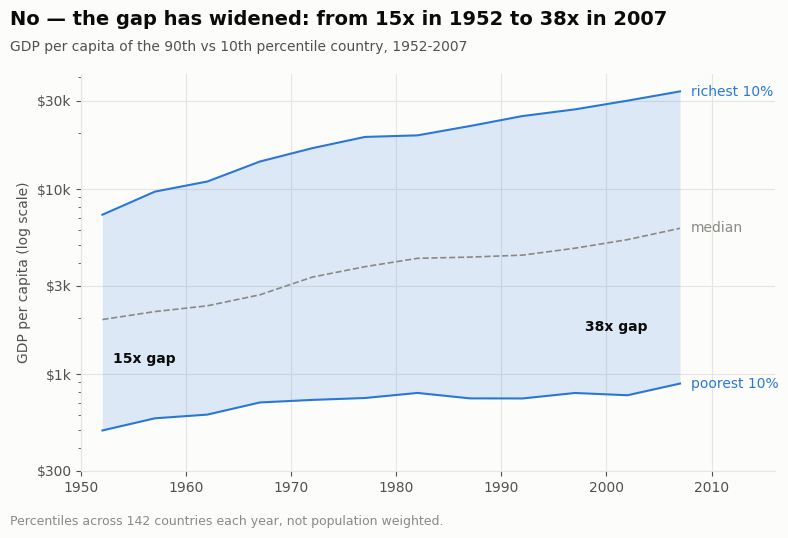

In [8]:
r0, r1 = pct["ratio"].iloc[0], pct["ratio"].iloc[-1]

fig, ax = plt.subplots()
ax.fill_between(pct.index, pct["p10"], pct["p90"], color=BLUE, alpha=0.15, linewidth=0)
ax.plot(pct.index, pct["p90"], color=BLUE)
ax.plot(pct.index, pct["p10"], color=BLUE)
ax.plot(pct.index, pct["median"], color=INK_MUTED, linestyle="--", linewidth=1.2)
ax.text(2008, pct["p90"].iloc[-1], "richest 10%", color=BLUE, va="center")
ax.text(2008, pct["median"].iloc[-1], "median", color=INK_MUTED, va="center")
ax.text(2008, pct["p10"].iloc[-1], "poorest 10%", color=BLUE, va="center")
ax.text(1953, 1150, f"{r0:.0f}x gap", color=INK, fontweight="bold")
ax.text(1998, 1700, f"{r1:.0f}x gap", color=INK, fontweight="bold")
ax.set_yscale("log")
ax.set_yticks([300, 1000, 3000, 10000, 30000])
ax.set_yticklabels(["$300", "$1k", "$3k", "$10k", "$30k"])
ax.set_xlim(1950, 2016)
ax.set_ylabel("GDP per capita (log scale)")

finish(fig, f"No — the gap has widened: from {r0:.0f}x in 1952 to {r1:.0f}x in 2007",
       "GDP per capita of the 90th vs 10th percentile country, 1952-2007",
       "Percentiles across 142 countries each year, not population weighted.",
       name="task2_gap")

**Chart analysis.**

The shaded band is the gap between rich and poor countries.  
The band gets wider over time, not thinner.  
Poor countries did get richer, but rich ones grew much faster.

**Why this chart:** it's a change over time so a line, and the question is about the *gap* so I shaded the
band between rich and poor — if it narrowed the band would get thinner. Log scale because the question is
relative (how many times richer). I used the 90th and 10th percentile instead of the single richest and
poorest country, because the max is very unstable: in 1952 the richest country was Kuwait at $108k (oil),
which would make the gap look like it shrank (363x → 178x) when really it's one outlier. Percentiles are
more honest.

Answer: the poor countries did get richer (the bottom line goes up a bit), but the rich ones grew much
faster, so the gap roughly doubled from about 15x to 38x.